# Exploratory Data Analysis

This notebook explores the interaction and product-metadata data using tables and visualizations.

The purpose is to understand:

- how ratings are distributed;
- how active different users are;
- how popular different products are;
- how interactions change over time;
- how complete the relevant product metadata is;
- whether popularity and activity are concentrated among a small number of products or users.

These charts describe the data. Final model development and comparison will use the documented time-aware train, validation and test procedure to prevent future information from leaking into evaluation.

In [7]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import numpy as np


In [8]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent


interaction_path = (
    project_root
    / "data"
    / "raw"
    / "Video_Games.csv.gz"
)

metadata_path = (
    project_root
    / "data"
    / "raw"
    / "meta_Video_Games.jsonl.gz"
)


interactions = pd.read_csv(interaction_path)

interactions["interaction_time"] = pd.to_datetime(
    interactions["timestamp"],
    unit="ms",
    utc=True,
)

print("Project root:", project_root)
print("Interaction-data shape:", interactions.shape)
print("Earliest interaction:", interactions["interaction_time"].min())
print("Latest interaction:", interactions["interaction_time"].max())

interactions.head()

Project root: /Users/trevaogwang/Documents/mobile-projects/saidia_recommeder
Interaction-data shape: (814586, 5)
Earliest interaction: 1999-10-22 21:43:15+00:00
Latest interaction: 2023-09-02 18:14:28.630000+00:00


,user_id,parent_asin,rating,timestamp,interaction_time
0,AEVPPTMG43C6GWSR7I2UGRQN7WFQ,B08R5B7YS4,1.0,1611459666223,2021-01-24 03:41:06.223000+00:00
1,AEVPPTMG43C6GWSR7I2UGRQN7WFQ,B0863MT183,4.0,1613701986538,2021-02-19 02:33:06.538000+00:00
2,AEVPPTMG43C6GWSR7I2UGRQN7WFQ,B08P8P7686,5.0,1613702112995,2021-02-19 02:35:12.995000+00:00
3,AEVPPTMG43C6GWSR7I2UGRQN7WFQ,B0B7LV3DN2,4.0,1617641445475,2021-04-05 16:50:45.475000+00:00
4,AEVPPTMG43C6GWSR7I2UGRQN7WFQ,B09WMQ6DXG,5.0,1620231368468,2021-05-05 16:16:08.468000+00:00


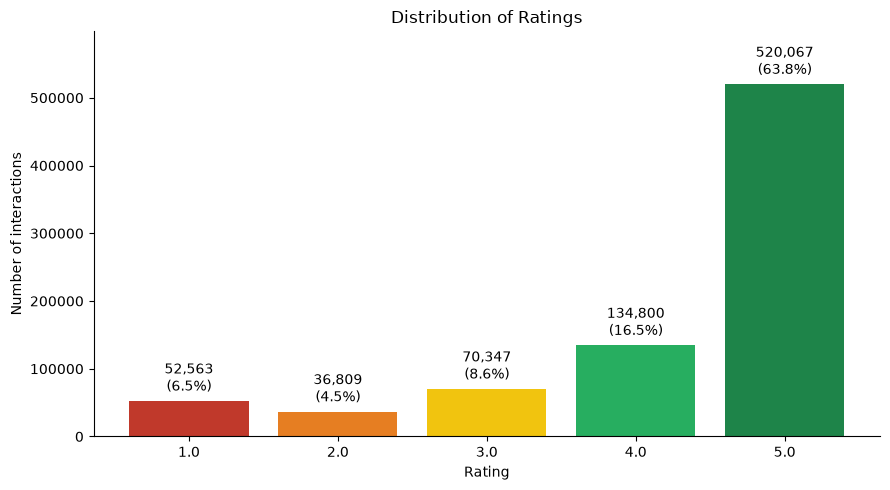

In [9]:
rating_counts = (
    interactions["rating"]
    .value_counts()
    .sort_index()
)

rating_percentages = (
    rating_counts
    / len(interactions)
    * 100
)


fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    color=[
        "#c0392b",
        "#e67e22",
        "#f1c40f",
        "#27ae60",
        "#1e8449",
    ],
)

ax.bar_label(
    bars,
    labels=[
        f"{count:,}\n({percentage:.1f}%)"
        for count, percentage in zip(
            rating_counts.values,
            rating_percentages.values,
        )
    ],
    padding=4,
)

ax.set_title("Distribution of Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of interactions")
ax.set_ylim(
    0,
    rating_counts.max() * 1.15,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation: rating distribution

The rating distribution is strongly concentrated toward high ratings:

- 520,067 interactions, or 63.8%, have a rating of 5;
- 134,800 interactions, or 16.5%, have a rating of 4;
- ratings of 4 or 5 account for 654,867 interactions, or approximately 80.4% of the dataset;
- ratings from 1 to 3 account for approximately 19.6%.

This supports the provisional definition of ratings 4 and 5 as positive interactions, but it also reveals a substantial class imbalance. A model that frequently predicts positive preference could appear successful if evaluated using an unsuitable metric.

The distribution does not prove that 80.4% of all customers like 80.4% of all products. It describes the ratings that appear in this filtered review dataset. Users may be more likely to review products they feel strongly about, and the 5-core filtering procedure also affects which users and products remain.

For recommendation evaluation, ranking metrics such as Hit Rate@K, Recall@K, MRR and NDCG@K will be more informative than simple classification accuracy.

,interactions_per_user
count,94762.000000
mean,8.596125
std,7.898208
min,5.000000
25%,5.000000
50%,6.000000
75%,9.000000
90%,14.000000
95%,19.000000
99%,38.000000


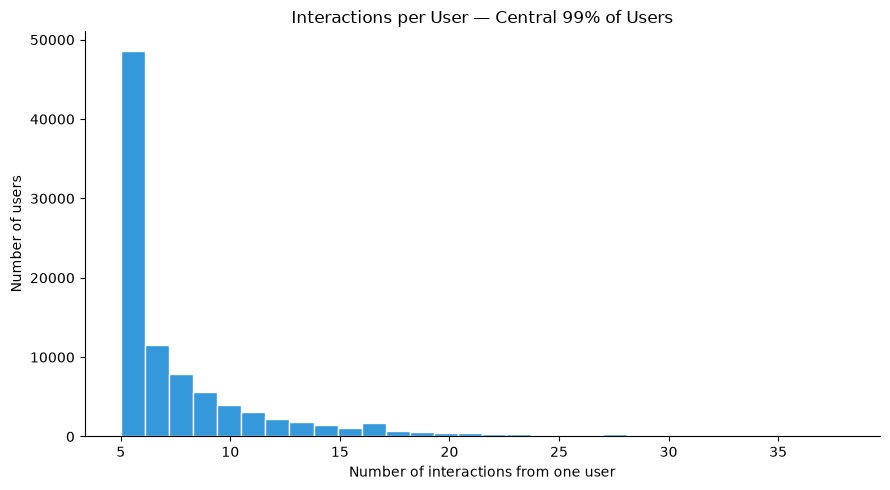

99th-percentile interaction count: 38
Users above the displayed range: 941
Maximum interactions from one user: 473


In [10]:
user_interaction_counts = (
    interactions
    .groupby("user_id")
    .size()
)

user_count_summary = (
    user_interaction_counts
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

display(
    user_count_summary.to_frame(
        name="interactions_per_user"
    )
)


user_99th_percentile = int(
    user_interaction_counts.quantile(0.99)
)

users_above_99th_percentile = (
    user_interaction_counts
    > user_99th_percentile
).sum()


fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    user_interaction_counts[
        user_interaction_counts
        <= user_99th_percentile
    ],
    bins=30,
    color="#3498db",
    edgecolor="white",
)

ax.set_title(
    "Interactions per User — Central 99% of Users"
)
ax.set_xlabel("Number of interactions from one user")
ax.set_ylabel("Number of users")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


print(
    "99th-percentile interaction count:",
    user_99th_percentile,
)

print(
    "Users above the displayed range:",
    users_above_99th_percentile,
)

print(
    "Maximum interactions from one user:",
    user_interaction_counts.max(),
)

### Interpretation: interactions per user

User activity has a right-skewed, long-tailed distribution.

The median user has 6 interactions, while the mean is approximately 8.60. The mean is higher because a relatively small number of highly active users contribute many more interactions than the typical user.

- 25% of users have exactly 5 interactions;
- 50% have 6 or fewer;
- 75% have 9 or fewer;
- 90% have 14 or fewer;
- 95% have 19 or fewer;
- 99% have 38 or fewer;
- the most active user has 473 interactions.

The minimum is 5 because this is a 5-core interaction dataset: every retained user and product has at least five interactions after the dataset provider's iterative filtering procedure.

The 941 users above the displayed 99th-percentile range were not deleted. They were omitted only from the displayed histogram so that the activity pattern of the majority remained visible.

This imbalance matters because highly active users contribute more training rows and may influence model learning more strongly. Evaluation metrics should therefore be calculated per user and then averaged, so that a highly active user does not automatically count hundreds of times more than a less active user.

,interactions_per_product
count,25612.000000
mean,31.804857
std,78.046151
min,5.000000
25%,7.000000
50%,12.000000
75%,26.000000
90%,64.000000
95%,120.000000
99%,340.890000


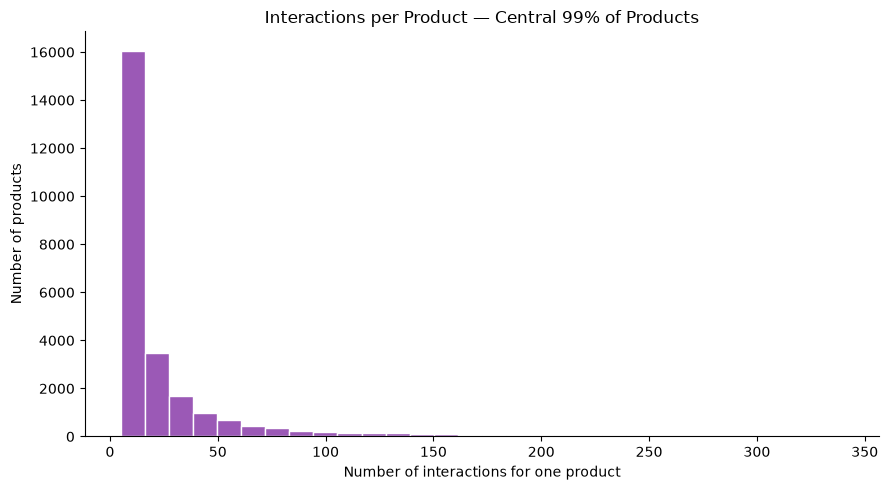

99th-percentile interaction count: 340
Products above the displayed range: 257
Maximum interactions for one product: 2955


In [11]:
product_interaction_counts = (
    interactions
    .groupby("parent_asin")
    .size()
)

product_count_summary = (
    product_interaction_counts
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

display(
    product_count_summary.to_frame(
        name="interactions_per_product"
    )
)


product_99th_percentile = int(
    product_interaction_counts.quantile(0.99)
)

products_above_99th_percentile = (
    product_interaction_counts
    > product_99th_percentile
).sum()


fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    product_interaction_counts[
        product_interaction_counts
        <= product_99th_percentile
    ],
    bins=30,
    color="#9b59b6",
    edgecolor="white",
)

ax.set_title(
    "Interactions per Product — Central 99% of Products"
)
ax.set_xlabel("Number of interactions for one product")
ax.set_ylabel("Number of products")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


print(
    "99th-percentile interaction count:",
    product_99th_percentile,
)

print(
    "Products above the displayed range:",
    products_above_99th_percentile,
)

print(
    "Maximum interactions for one product:",
    product_interaction_counts.max(),
)

### Interpretation: interactions per product

Product popularity has a strongly right-skewed, long-tailed distribution.

The median product has 12 interactions, while the mean is approximately 31.8. This difference indicates that a relatively small number of highly popular products receive far more interactions than the typical product.

- 25% of products have 7 or fewer interactions;
- 50% have 12 or fewer;
- 75% have 26 or fewer;
- 90% have 64 or fewer;
- 95% have 120 or fewer;
- 99% have approximately 341 or fewer;
- the most frequently rated product has 2,955 interactions.

The minimum is 5 because the interaction file is a 5-core dataset.

The 257 products above the displayed range were not removed. They were omitted only from this histogram so that the distribution among the central 99% of products remained readable.

This popularity imbalance matters because a recommender can achieve reasonable accuracy by repeatedly recommending popular products. Model evaluation should therefore compare learned recommenders against a popularity baseline and should also inspect recommendation coverage and popularity bias.

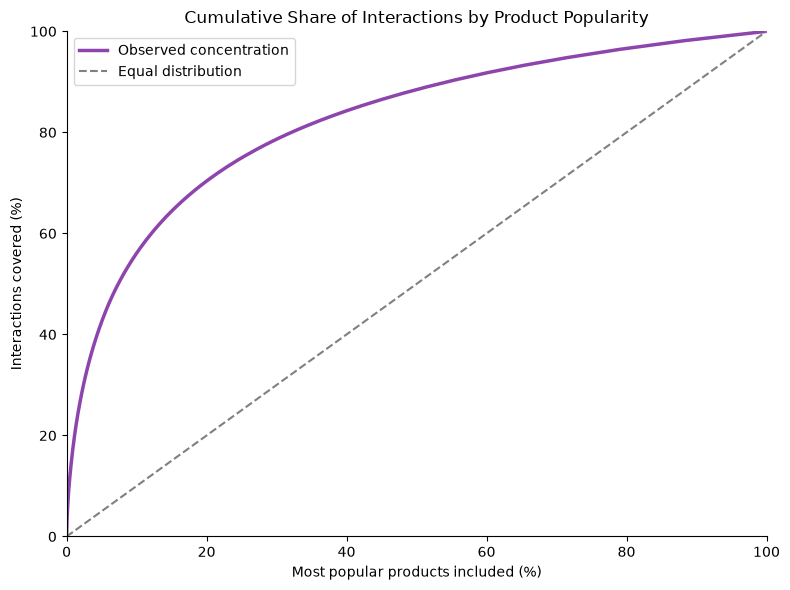

Top 1% of products (257) account for 18.63% of interactions.
Top 5% of products (1,281) account for 42.50% of interactions.
Top 10% of products (2,562) account for 56.09% of interactions.


In [12]:
sorted_product_counts = (
    product_interaction_counts
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

cumulative_interaction_share = (
    sorted_product_counts.cumsum()
    / sorted_product_counts.sum()
    * 100
)

cumulative_product_share = (
    (
        np.arange(len(sorted_product_counts))
        + 1
    )
    / len(sorted_product_counts)
    * 100
)


def top_product_interaction_share(fraction):
    number_of_products = max(
        1,
        int(
            np.ceil(
                len(sorted_product_counts)
                * fraction
            )
        ),
    )

    interaction_share = (
        sorted_product_counts.iloc[
            :number_of_products
        ].sum()
        / sorted_product_counts.sum()
        * 100
    )

    return number_of_products, interaction_share


top_1_count, top_1_share = (
    top_product_interaction_share(0.01)
)

top_5_count, top_5_share = (
    top_product_interaction_share(0.05)
)

top_10_count, top_10_share = (
    top_product_interaction_share(0.10)
)


fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    cumulative_product_share,
    cumulative_interaction_share,
    color="#8e44ad",
    linewidth=2.5,
    label="Observed concentration",
)

ax.plot(
    [0, 100],
    [0, 100],
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Equal distribution",
)

ax.set_title(
    "Cumulative Share of Interactions by Product Popularity"
)
ax.set_xlabel(
    "Most popular products included (%)"
)
ax.set_ylabel(
    "Interactions covered (%)"
)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()

plt.tight_layout()
plt.show()


print(
    f"Top 1% of products ({top_1_count:,}) "
    f"account for {top_1_share:.2f}% of interactions."
)

print(
    f"Top 5% of products ({top_5_count:,}) "
    f"account for {top_5_share:.2f}% of interactions."
)

print(
    f"Top 10% of products ({top_10_count:,}) "
    f"account for {top_10_share:.2f}% of interactions."
)

### Interpretation: cumulative product popularity

Interaction activity is substantially concentrated among the most popular products.

- The top 1% of products, representing 257 products, account for 18.63% of all interactions.
- The top 5%, representing 1,281 products, account for 42.58%.
- The top 10%, representing 2,562 products, account for 56.09%.

This means that the remaining 90% of products collectively receive only 43.91% of interactions.

The purple curve lies well above the equal-distribution line. If every product received an equal share of interactions, including 10% of products would cover approximately 10% of interactions. Instead, the most popular 10% cover more than half of the dataset.

This concentration creates a strong popularity signal. A simple popularity-based recommender may therefore achieve meaningful ranking performance even without learning individual preferences. It should be included as a baseline against which more personalized models are compared.

Accuracy alone will not completely describe recommendation quality. Later evaluation should also consider:

- catalog coverage: how many different products the model recommends;
- popularity bias: whether recommendations are dominated by popular products;
- novelty: whether users receive relevant products they may not already know;
- personalization: whether different users receive meaningfully different lists.

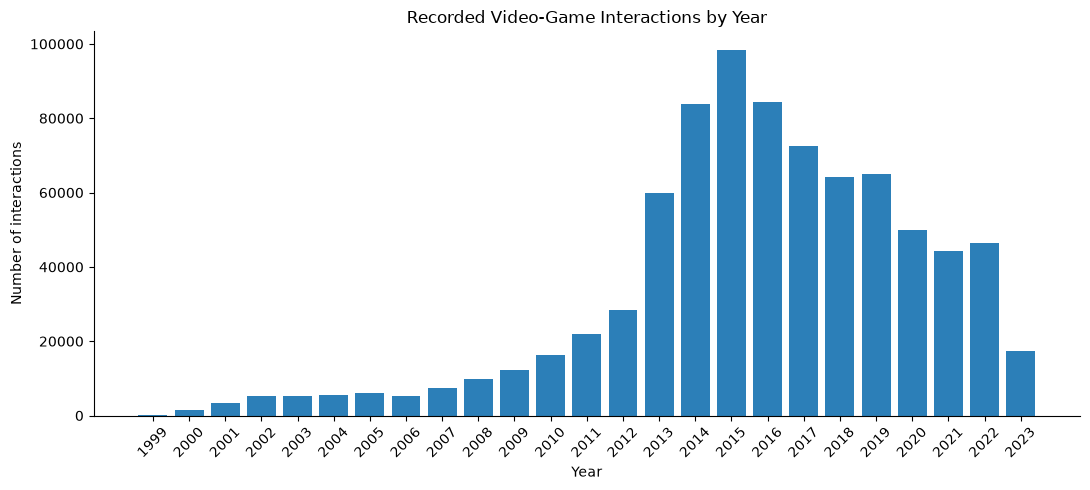

First year in the data: 1999
Last year in the data: 2023
Year with the most recorded interactions: 2015
Interactions in the peak year: 98,466


,interaction_count
interaction_time,
1999,57
2000,1362
2001,3471
2002,5185
2003,5201
2004,5548
2005,6064
2006,5274
2007,7404


In [13]:
yearly_interaction_counts = (
    interactions["interaction_time"]
    .dt.year
    .value_counts()
    .sort_index()
)


fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    yearly_interaction_counts.index,
    yearly_interaction_counts.values,
    color="#2c7fb8",
)

ax.set_title(
    "Recorded Video-Game Interactions by Year"
)
ax.set_xlabel("Year")
ax.set_ylabel("Number of interactions")

ax.set_xticks(
    yearly_interaction_counts.index
)
ax.tick_params(
    axis="x",
    rotation=45,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


peak_year = yearly_interaction_counts.idxmax()
peak_year_count = yearly_interaction_counts.max()

print(
    "First year in the data:",
    yearly_interaction_counts.index.min(),
)

print(
    "Last year in the data:",
    yearly_interaction_counts.index.max(),
)

print(
    "Year with the most recorded interactions:",
    peak_year,
)

print(
    "Interactions in the peak year:",
    f"{peak_year_count:,}",
)

display(
    yearly_interaction_counts.to_frame(
        name="interaction_count"
    )
)

### Interpretation: interactions over time

The number of recorded interactions changes substantially across the dataset's time range.

Interaction volume grows gradually during the early years, rises sharply between 2012 and 2015, and reaches its highest level in 2015 with 98,466 interactions. Recorded interaction volume generally declines after 2015, although some later years show small increases.

The first and last years are incomplete observation periods:

- the first recorded interaction occurred in October 1999;
- the latest recorded interaction occurred in September 2023.

Therefore, the low counts in 1999 and 2023 should not be directly compared with complete calendar years.

These changes describe the records contained in this dataset. They do not by themselves prove that total video-game demand or Amazon sales followed the same pattern. Changes could also reflect review activity, product availability, data-collection coverage or platform behaviour.

The changing interaction volume supports the use of time-aware evaluation. A random split could train a model using newer interactions and then test it on older interactions, which would not represent a realistic recommendation process.

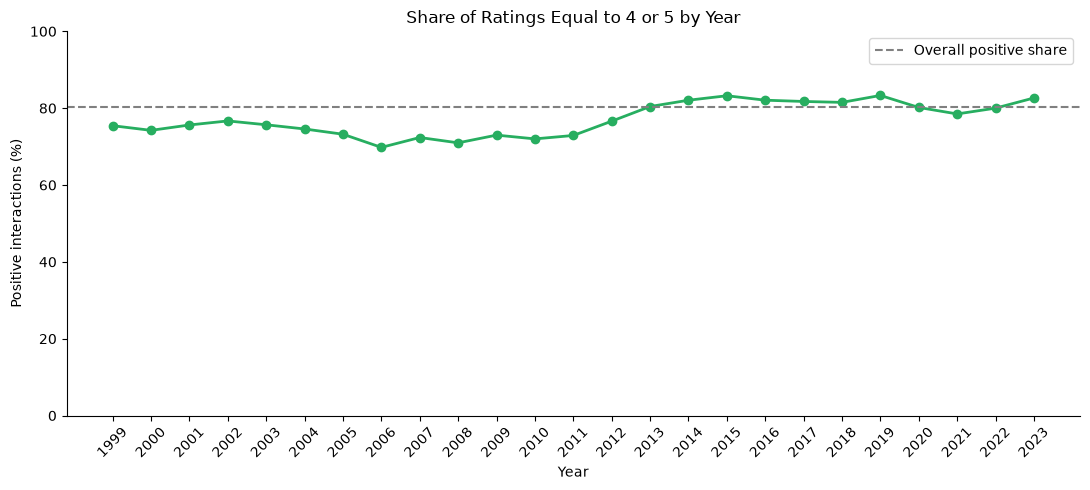

,total_interactions,positive_interactions,positive_percentage
interaction_time,,,
1999,57,43,75.44
2000,1362,1011,74.23
2001,3471,2625,75.63
2002,5185,3976,76.68
2003,5201,3936,75.68
2004,5548,4138,74.59
2005,6064,4440,73.22
2006,5274,3681,69.80
2007,7404,5358,72.37


In [15]:
eda_interactions = interactions.assign(
    is_positive=interactions["rating"] >= 4
)


yearly_positive_summary = (
    eda_interactions
    .groupby(
        eda_interactions["interaction_time"].dt.year
    )
    .agg(
        total_interactions=("rating", "size"),
        positive_interactions=("is_positive", "sum"),
    )
)

yearly_positive_summary["positive_percentage"] = (
    yearly_positive_summary["positive_interactions"]
    / yearly_positive_summary["total_interactions"]
    * 100
)


fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    yearly_positive_summary.index,
    yearly_positive_summary["positive_percentage"],
    color="#27ae60",
    marker="o",
    linewidth=2,
)

ax.axhline(
    y=(
        eda_interactions["is_positive"].mean()
        * 100
    ),
    color="gray",
    linestyle="--",
    label="Overall positive share",
)

ax.set_title(
    "Share of Ratings Equal to 4 or 5 by Year"
)
ax.set_xlabel("Year")
ax.set_ylabel("Positive interactions (%)")

ax.set_xticks(
    yearly_positive_summary.index
)
ax.tick_params(
    axis="x",
    rotation=45,
)

ax.set_ylim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()

plt.tight_layout()
plt.show()


display(
    yearly_positive_summary.round(2)
)

### Interpretation: positive-interaction share over time

The percentage of interactions rated 4 or 5 changes across the observation period.

Earlier years generally have positive-interaction shares between approximately 70% and 77%. The lowest observed annual share is 69.80% in 2006.

The positive share begins rising after 2011 and reaches 80.43% in 2013. From 2013 onward, it generally remains near or above the overall dataset share of approximately 80.4%. The highest observed share is 83.31% in 2019.

The 1999 and 2023 percentages require additional caution because those years are incomplete. In particular, 1999 contains only 57 interactions, so its percentage is based on a very small sample.

This pattern provides evidence of temporal drift: the proportion of ratings classified as positive changes over time. The chart does not explain the cause. Possible influences include changes in the users, products, review behaviour or dataset coverage.

This supports chronological evaluation because later feedback does not have exactly the same distribution as earlier feedback.

The planned leave-two-out procedure is chronological within each user: it prevents that user's validation and test interactions from entering that user's training history. It is not a strict global-date simulation because training information from other users may come from later calendar dates. A future robustness evaluation may additionally use a global time cutoff to simulate deployment at one specific date.

In [16]:
metadata = pd.read_json(
    metadata_path,
    lines=True,
    compression="gzip",
)


interaction_product_ids = set(
    interactions["parent_asin"].unique()
)


interaction_metadata = (
    metadata[
        metadata["parent_asin"].isin(
            interaction_product_ids
        )
    ]
    .copy()
)


print(
    "Complete metadata shape:",
    metadata.shape,
)

print(
    "Products in interaction data:",
    len(interaction_product_ids),
)

print(
    "Relevant metadata shape:",
    interaction_metadata.shape,
)

print(
    "Unique relevant metadata products:",
    interaction_metadata["parent_asin"].nunique(),
)

interaction_metadata.head()

Complete metadata shape: (137269, 16)
Products in interaction data: 25612
Relevant metadata shape: (25612, 16)
Unique relevant metadata products: 25612


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
2,Video Games,NBA 2K17 - Early Tip Off Edition - PlayStation 4,4.3,223,[The #1 rated NBA video game simulation series...,[Following the record-breaking launch of NBA 2...,58.0,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'NBA 2K17 - Kobe: Haters vs Players...,2K,"[Video Games, PlayStation 4, Games]","{'Release date': 'September 16, 2016', 'Best S...",B00Z9TLVK0,NaN,NaN,NaN
7,Video Games,eXtremeRate Soft Touch Top Shell Front Housing...,4.5,3061,[Compatibility Models: Ultra fits for Xbox One...,[],17.59,[{'thumb': 'https://m.media-amazon.com/images/...,[],eXtremeRate,"[Video Games, Xbox One, Accessories, Faceplate...","{'Best Sellers Rank': {'Video Games': 48130, '...",B07H93H878,NaN,NaN,NaN
9,Video Games,Konami Collector's Series: Castlevania & Contr...,3.6,19,[This collection of classic 8-bit games includ...,[The Konami Collector's Series: Castlevania & ...,None,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Konami Collector's Series: Arcade ...,Square Enix,"[Video Games, PC, Games]","{'Release date': 'December 2, 2002', 'Best Sel...",B00006969T,NaN,NaN,NaN
10,Video Games,Tales of Vesperia - Definitive Edition - PlayS...,4.8,1389,[A BELOVED TALE RETURNS! — The tale of a young...,[A power struggle begins in a Civilization dep...,20.95,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Tales of Vesperia - Definitive Edi...,BANDAI NAMCO Entertainment,"[Video Games, PlayStation 4, Games]","{'Release date': 'January 11, 2019', 'Best Sel...",B07DL353F8,NaN,NaN,NaN
11,Video Games,Turbo: Super Stunt Squad - Nintendo 3DS,4.1,26,[Play as your favorite snails from the movie -...,"[Product Description, Turbo: Super Stunt Squad...",4.97,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Turbo: Super Stunt Squad - Launch'...,D3 Publisher,"[Video Games, Legacy Systems, Nintendo Systems...","{'Release date': 'July 16, 2013', 'Best Seller...",B00BJH85SW,NaN,NaN,NaN


### Relevant product-metadata subset

The complete metadata file contains 137,269 product records. The interaction data references 25,612 unique products.

Filtering the complete metadata using the interaction product identifiers produced 25,612 metadata records representing 25,612 unique products.

Therefore, every product in the interaction dataset has a matching metadata record. The following analysis focuses on this relevant 25,612-product subset rather than products that do not appear in the current recommendation dataset.

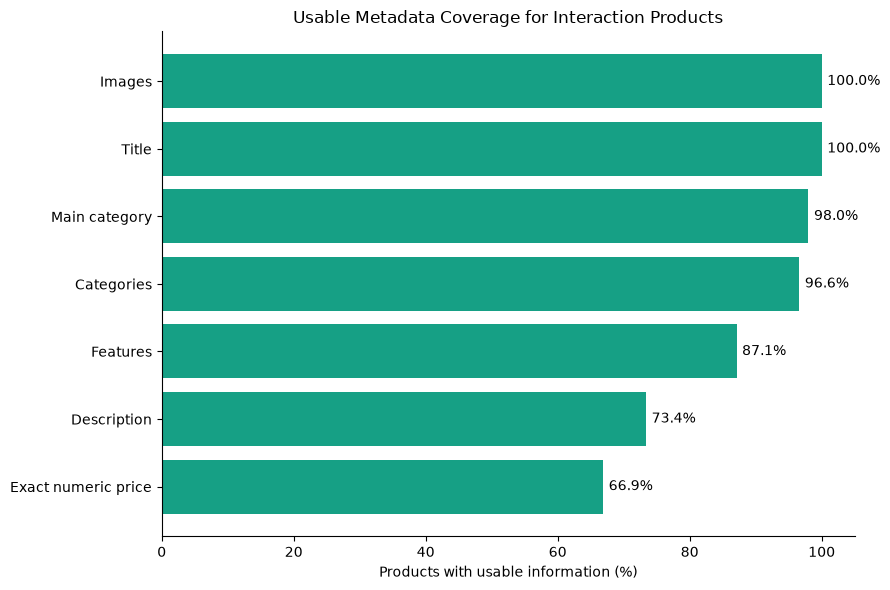

,usable_percentage
Exact numeric price,66.89
Description,73.39
Features,87.10
Categories,96.61
Main category,97.99
Title,100.00
Images,100.00


In [17]:
def contains_usable_list_content(value):
    if not isinstance(value, list):
        return False

    return any(
        str(item).strip()
        for item in value
    )


has_usable_title = (
    interaction_metadata["title"]
    .astype("string")
    .fillna("")
    .str.strip()
    .ne("")
)

has_usable_main_category = (
    interaction_metadata["main_category"]
    .astype("string")
    .fillna("")
    .str.strip()
    .ne("")
)

has_usable_description = (
    interaction_metadata["description"]
    .apply(contains_usable_list_content)
)

has_usable_features = (
    interaction_metadata["features"]
    .apply(contains_usable_list_content)
)

has_usable_categories = (
    interaction_metadata["categories"]
    .apply(contains_usable_list_content)
)

has_usable_images = (
    interaction_metadata["images"]
    .apply(contains_usable_list_content)
)

exact_numeric_price = pd.to_numeric(
    interaction_metadata["price"],
    errors="coerce",
)

has_exact_numeric_price = (
    exact_numeric_price.notna()
)


metadata_usability = pd.Series(
    {
        "Title": has_usable_title.mean() * 100,
        "Main category": (
            has_usable_main_category.mean() * 100
        ),
        "Description": (
            has_usable_description.mean() * 100
        ),
        "Features": (
            has_usable_features.mean() * 100
        ),
        "Categories": (
            has_usable_categories.mean() * 100
        ),
        "Images": (
            has_usable_images.mean() * 100
        ),
        "Exact numeric price": (
            has_exact_numeric_price.mean() * 100
        ),
    }
).sort_values()


fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    metadata_usability.index,
    metadata_usability.values,
    color="#16a085",
)

ax.bar_label(
    bars,
    labels=[
        f"{percentage:.1f}%"
        for percentage in metadata_usability.values
    ],
    padding=4,
)

ax.set_title(
    "Usable Metadata Coverage for Interaction Products"
)
ax.set_xlabel("Products with usable information (%)")
ax.set_xlim(0, 105)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


metadata_usability.to_frame(
    name="usable_percentage"
).round(2)

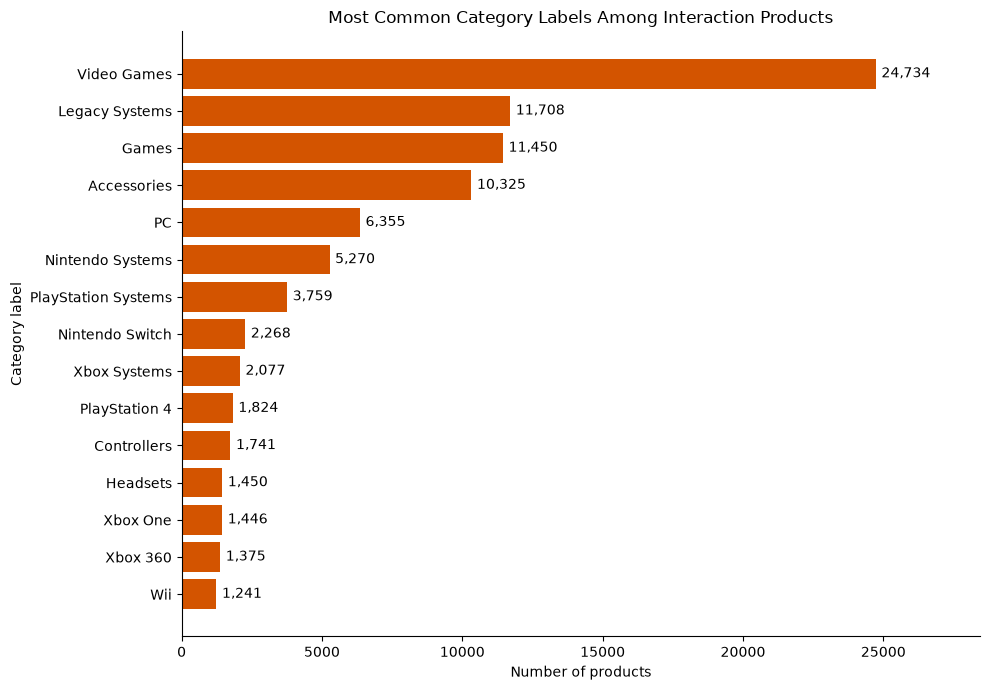

Products with at least one usable category: 24743
Unique category labels: 161


In [18]:
product_category_tags = (
    interaction_metadata[
        ["parent_asin", "categories"]
    ]
    .explode("categories")
    .dropna(subset=["categories"])
)


product_category_tags["categories"] = (
    product_category_tags["categories"]
    .astype(str)
    .str.strip()
)


product_category_tags = (
    product_category_tags[
        product_category_tags["categories"].ne("")
    ]
    .drop_duplicates(
        subset=["parent_asin", "categories"]
    )
)


category_product_counts = (
    product_category_tags["categories"]
    .value_counts()
)


top_category_counts = (
    category_product_counts
    .head(15)
    .sort_values()
)


fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_category_counts.index,
    top_category_counts.values,
    color="#d35400",
)

ax.bar_label(
    bars,
    labels=[
        f"{count:,}"
        for count in top_category_counts.values
    ],
    padding=4,
)

ax.set_title(
    "Most Common Category Labels Among Interaction Products"
)
ax.set_xlabel("Number of products")
ax.set_ylabel("Category label")

ax.set_xlim(
    0,
    top_category_counts.max() * 1.15,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


print(
    "Products with at least one usable category:",
    product_category_tags["parent_asin"].nunique(),
)

print(
    "Unique category labels:",
    product_category_tags["categories"].nunique(),
)

### Interpretation: product-category labels

Among the 25,612 interaction products, 24,743 have at least one usable category label. The metadata contains 161 unique category labels.

The category system is hierarchical and overlapping. A product may simultaneously be labelled as:

- Video Games;
- Nintendo Systems;
- Nintendo Switch;
- Games.

Therefore, the category counts should not be added together as though they represent separate groups.

`Video Games` appears on 24,734 products and is too common to distinguish one product from another effectively. General labels such as `Games` and `Legacy Systems` also provide limited detail by themselves.

More specific labels including platform labels such as `PC`, `Nintendo Switch`, `PlayStation 4`, `Xbox One` and `Wii`—can provide more useful content-similarity signals.

The catalog also contains accessories such as controllers and headsets. This means the recommendation system is not working exclusively with playable games.

For content-based modelling, common labels should contribute less than distinctive labels. A TF-IDF representation can help accomplish this automatically by assigning lower weight to terms that appear on many products and higher weight to less-common, more-informative terms.

,exact_numeric_price
count,17131.000000
mean,52.909762
std,86.958666
min,0.000000
25%,16.990000
50%,29.910000
75%,52.000000
90%,107.980000
95%,185.185000
99%,397.676000


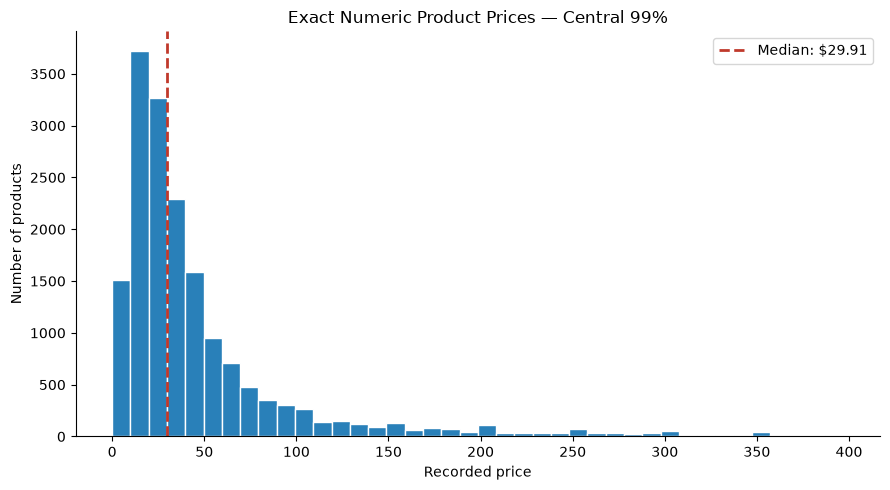

Products with an exact numeric price: 17131
Products with a recorded zero price: 6
99th-percentile price: $397.68
Products above the displayed range: 172
Maximum exact numeric price: $2189.75


In [19]:
exact_prices = (
    exact_numeric_price
    .dropna()
)

price_summary = exact_prices.describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

display(
    price_summary.to_frame(
        name="exact_numeric_price"
    )
)


price_99th_percentile = (
    exact_prices.quantile(0.99)
)

prices_above_display_range = (
    exact_prices
    > price_99th_percentile
).sum()

zero_price_count = (
    exact_prices == 0
).sum()


fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    exact_prices[
        exact_prices
        <= price_99th_percentile
    ],
    bins=40,
    color="#2980b9",
    edgecolor="white",
)

ax.axvline(
    exact_prices.median(),
    color="#c0392b",
    linestyle="--",
    linewidth=2,
    label=(
        f"Median: "
        f"${exact_prices.median():.2f}"
    ),
)

ax.set_title(
    "Exact Numeric Product Prices — Central 99%"
)
ax.set_xlabel("Recorded price")
ax.set_ylabel("Number of products")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()

plt.tight_layout()
plt.show()


print(
    "Products with an exact numeric price:",
    len(exact_prices),
)

print(
    "Products with a recorded zero price:",
    zero_price_count,
)

print(
    "99th-percentile price:",
    f"${price_99th_percentile:.2f}",
)

print(
    "Products above the displayed range:",
    prices_above_display_range,
)

print(
    "Maximum exact numeric price:",
    f"${exact_prices.max():.2f}",
)

In [20]:
zero_price_mask = (
    exact_numeric_price == 0
)


zero_price_products = (
    interaction_metadata.loc[
        zero_price_mask,
        [
            "parent_asin",
            "title",
            "price",
            "main_category",
            "categories",
        ],
    ]
    .copy()
)


zero_price_products["price_numeric"] = (
    exact_numeric_price.loc[
        zero_price_mask
    ]
)


display(
    zero_price_products[
        [
            "parent_asin",
            "title",
            "price",
            "price_numeric",
            "main_category",
            "categories",
        ]
    ]
)

,parent_asin,title,price,price_numeric,main_category,categories
14614,B00H8618QO,Prime World [Download],0.0,0.0,Video Games,"[Video Games, PC, Games]"
73023,B00I0E5J5Y,Path of Exile [Download],0.0,0.0,Video Games,"[Video Games, PC, Games]"
80576,B00GPQ2ZOW,Block Puzzle [Download],0.0,0.0,Video Games,"[Video Games, PC, Games]"
82159,B00HRKDECC,RAN Online [Download],0.0,0.0,Video Games,"[Video Games, PC, Games]"
82875,B00F0Q7N1I,Lord Of The Rings Online [Download],0.0,0.0,Video Games,"[Video Games, PC, Games]"
90282,B008773WWQ,Raptr [Download],0.0,0.0,Software,"[Video Games, PC, Games]"


In [21]:
displayed_prices = exact_prices[
    exact_prices <= price_99th_percentile
]

histogram_counts, histogram_edges = np.histogram(
    displayed_prices,
    bins=40,
)

first_bin_start = histogram_edges[0]
first_bin_end = histogram_edges[1]
first_bin_count = histogram_counts[0]

print(
    f"First bar range: "
    f"${first_bin_start:.2f} to below ${first_bin_end:.2f}"
)

print(
    "All products in the first bar:",
    first_bin_count,
)

print(
    "Products priced exactly at zero:",
    (displayed_prices == 0).sum(),
)

print(
    "Non-zero products in the first bar:",
    first_bin_count
    - (displayed_prices == 0).sum(),
)

First bar range: $0.00 to below $9.92
All products in the first bar: 1509
Products priced exactly at zero: 6
Non-zero products in the first bar: 1503


### Interpretation: exact numeric price distribution

Exact numeric prices are available for 17,131 of the 25,612 interaction products.

The price distribution is strongly right-skewed:

- 25% of exact prices are at or below $16.99;
- the median exact price is $29.91;
- 75% are at or below $52.00;
- 90% are at or below $107.98;
- 95% are at or below $185.19;
- 99% are at or below $397.68;
- the maximum recorded exact price is $2,189.75.

The mean price, approximately $52.91, is considerably higher than the median because a small number of expensive products pull the mean upward.

The histogram displays the central 99% of exact prices. The 172 products above $397.68 remain in the data but are not displayed so that the main price distribution remains readable.

Six products have a recorded exact price of zero. These represent approximately 0.04% of products with exact numeric prices. They are too rare to appear separately in the histogram and are documented using an exact count and inspection table instead.

Recorded prices are metadata snapshots and may not represent the price available when a historical rating was submitted. Price will therefore not automatically be used as a temporal model feature.

### Interpretation: exact numeric price distribution

Exact numeric prices are available for 17,131 of the 25,612 interaction products.

The price distribution is strongly right-skewed:

- 25% of exact prices are at or below $16.99;
- the median exact price is $29.91;
- 75% are at or below $52.00;
- 90% are at or below $107.98;
- 95% are at or below $185.19;
- 99% are at or below $397.68;
- the maximum recorded exact price is $2,189.75.

The mean price, approximately $52.91, is considerably higher than the median because a small number of expensive products pull the mean upward.

The histogram displays the central 99% of exact prices. The 172 products above $397.68 remain in the data but are not displayed so that the main price distribution remains readable.

Six products have a recorded exact price of zero. These represent approximately 0.04% of products with exact numeric prices. They are too rare to appear separately in the histogram and are documented using an exact count and inspection table instead.

Recorded prices are metadata snapshots and may not represent the price available when a historical rating was submitted. Price will therefore not automatically be used as a temporal model feature.

In [22]:
number_of_users = (
    interactions["user_id"].nunique()
)

number_of_products = (
    interactions["parent_asin"].nunique()
)

observed_user_product_pairs = (
    interactions[
        ["user_id", "parent_asin"]
    ]
    .drop_duplicates()
    .shape[0]
)

possible_user_product_pairs = (
    number_of_users
    * number_of_products
)

interaction_density = (
    observed_user_product_pairs
    / possible_user_product_pairs
    * 100
)

interaction_sparsity = (
    100
    - interaction_density
)


print(
    "Users:",
    f"{number_of_users:,}",
)

print(
    "Products:",
    f"{number_of_products:,}",
)

print(
    "Possible user-product pairs:",
    f"{possible_user_product_pairs:,}",
)

print(
    "Observed user-product pairs:",
    f"{observed_user_product_pairs:,}",
)

print(
    f"Interaction density: "
    f"{interaction_density:.6f}%"
)

print(
    f"Interaction sparsity: "
    f"{interaction_sparsity:.6f}%"
)

Users: 94,762
Products: 25,612
Possible user-product pairs: 2,427,044,344
Observed user-product pairs: 814,586
Interaction density: 0.033563%
Interaction sparsity: 99.966437%


### Interpretation: user–product interaction sparsity

The interaction dataset contains:

- 94,762 unique users;
- 25,612 unique products;
- 2,427,044,344 theoretically possible user–product pairs;
- 814,586 observed user–product pairs.

Only approximately 0.0336% of all possible user–product relationships are observed. The resulting interaction matrix is approximately 99.9664% sparse.

This means that almost every possible user–product relationship is unknown. An unobserved pair does not prove that the user dislikes the product. The user may never have encountered, purchased or rated it.

The dataset is 5-core, so every retained user and product has at least five interactions. However, 5-core filtering does not make the complete user–product matrix dense. Each user still interacts with only a very small fraction of the 25,612 available products.

This sparsity is a central recommendation challenge. Collaborative-filtering models attempt to learn preference patterns from the small observed portion of the matrix and use those patterns to score unobserved products.

When training ranking models, unobserved products may be sampled as comparison candidates. These are commonly called negative samples, but they must be interpreted carefully: they are unobserved examples, not confirmed dislikes.